In [1]:
import pandas as pd

df = pd.read_csv("/content/cs-training.csv")
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [2]:
df.shape
df.info()
df.isnull().sum()
df['SeriousDlqin2yrs'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

,count
SeriousDlqin2yrs,
0,139974
1,10026


In [3]:
df.fillna(df.median(), inplace=True)

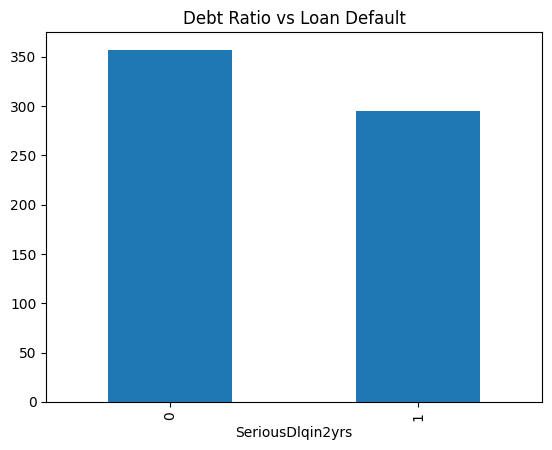

In [4]:
import matplotlib.pyplot as plt

df.groupby('SeriousDlqin2yrs')['DebtRatio'].mean().plot(kind='bar')
plt.title("Debt Ratio vs Loan Default")
plt.show()

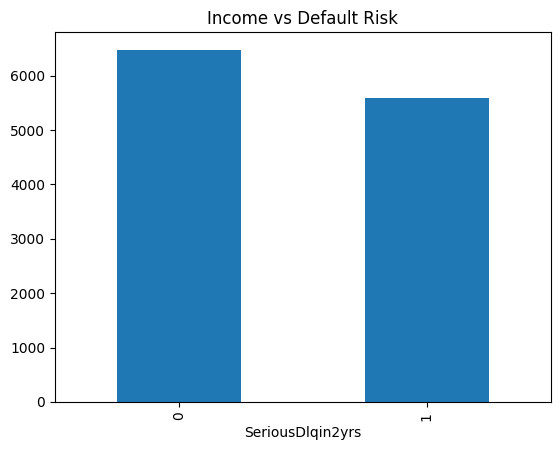

In [5]:
df.groupby('SeriousDlqin2yrs')['MonthlyIncome'].mean().plot(kind='bar')
plt.title("Income vs Default Risk")
plt.show()

/tmp/ipykernel_7055/1136541051.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['SeriousDlqin2yrs'].mean().plot(kind='line', marker='o')


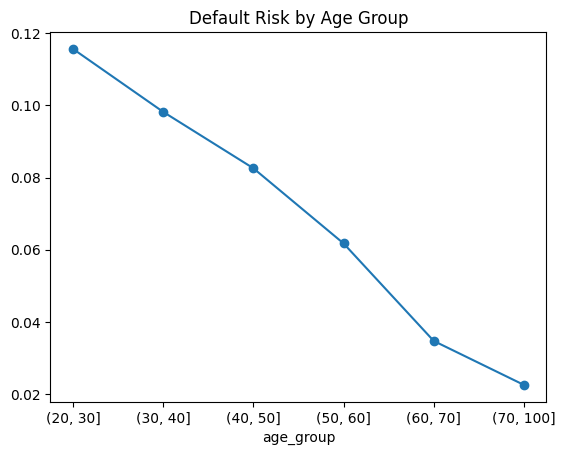

In [6]:
df['age_group'] = pd.cut(df['age'], bins=[20,30,40,50,60,70,100])

df.groupby('age_group')['SeriousDlqin2yrs'].mean().plot(kind='line', marker='o')
plt.title("Default Risk by Age Group")
plt.show()

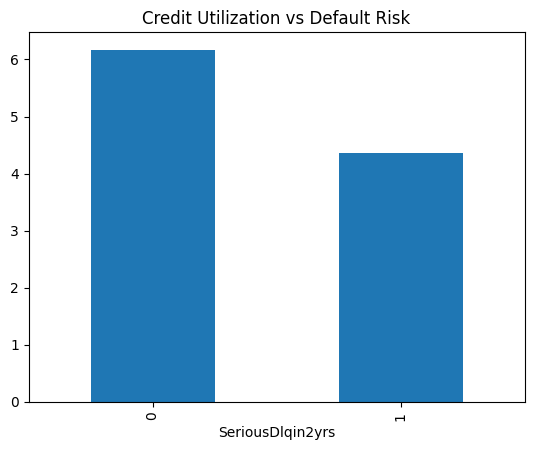

In [7]:
df.groupby('SeriousDlqin2yrs')['RevolvingUtilizationOfUnsecuredLines'].mean().plot(kind='bar')
plt.title("Credit Utilization vs Default Risk")
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Drop the 'age_group' column from X_train and X_test as it contains non-numerical interval objects
X_train = X_train.drop('age_group', axis=1)
X_test = X_test.drop('age_group', axis=1)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [14]:
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [15]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9373
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     28044
           1       0.56      0.18      0.28      1956

    accuracy                           0.94     30000
   macro avg       0.75      0.59      0.62     30000
weighted avg       0.92      0.94      0.92     30000



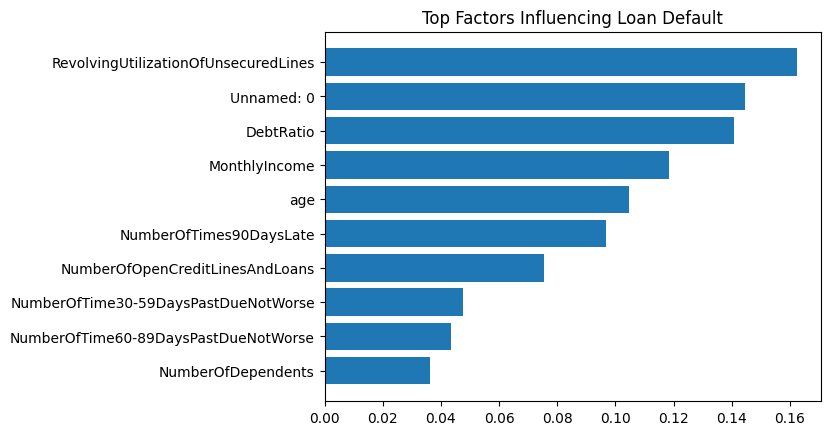

In [16]:
import numpy as np

importances = rf.feature_importances_
features = df.drop('SeriousDlqin2yrs', axis=1).columns

sorted_idx = np.argsort(importances)[-10:]

plt.barh(features[sorted_idx], importances[sorted_idx])
plt.title("Top Factors Influencing Loan Default")
plt.show()

In [17]:
import joblib

joblib.dump(rf, "credit_risk_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']